# 02 — EDA

Exploratory data analysis on the UCI Online Retail II dataset.

Data quality and scope justification are assessed on the **bronze** layer
(raw, all countries, with nulls); behavioural analysis runs on the **silver**
layer (cleaned, UK-only, purchases + returns).

In [1]:
import sys
from pathlib import Path

sys.path.insert(0, str(Path.cwd().parent))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from src.config import load_settings
from src.viz import set_style
from src.data import split_purchases_returns

set_style()

ROOT = Path.cwd().parent
settings = load_settings(ROOT / "config" / "settings.yaml")

FIG_DIR = ROOT / settings["paths"]["reports"] / "figures"
TBL_DIR = ROOT / settings["paths"]["reports"] / "tables"
FIG_DIR.mkdir(parents=True, exist_ok=True)
TBL_DIR.mkdir(parents=True, exist_ok=True)


def savefig(fig, name):
    fig.savefig(FIG_DIR / f"02_{name}.png", dpi=150, bbox_inches="tight")


def savetable(df, name):
    df.to_csv(TBL_DIR / f"02_{name}.csv")

In [2]:
bronze = pd.read_parquet(ROOT / settings["paths"]["bronze"] / "transactions_concat.parquet")
silver = pd.read_parquet(ROOT / settings["paths"]["silver"] / "transactions_clean.parquet")
print("bronze (raw, all countries):", bronze.shape)
print("silver (clean, UK)        :", silver.shape)

bronze (raw, all countries): (1067371, 8)
silver (clean, UK)        : (714764, 9)


## 1. Dataset overview & schema

In [3]:
print("Date range :", bronze["InvoiceDate"].min(), "->", bronze["InvoiceDate"].max())
print("Invoices   :", bronze["Invoice"].nunique())
print("Stock codes:", bronze["StockCode"].nunique())
print("Customers  :", bronze["Customer ID"].nunique())
print("Countries  :", bronze["Country"].nunique())
bronze.dtypes

Date range : 2009-12-01 07:45:00 -> 2011-12-09 12:50:00
Invoices   : 53628
Stock codes: 5305
Customers  : 5942
Countries  : 43


Invoice                string
StockCode              string
Description            string
Quantity                int64
InvoiceDate    datetime64[us]
Price                 float64
Customer ID           float64
Country                   str
dtype: object

## 2. Data quality

Missing values, invalid rows, and the cleaning funnel that produces the silver layer.

In [4]:
quality = pd.DataFrame({
    "nulls": bronze.isna().sum(),
    "null_pct": (bronze.isna().mean() * 100).round(2),
})
print("Negative or zero quantity:", int((bronze["Quantity"] <= 0).sum()))
print("Negative or zero price   :", int((bronze["Price"] <= 0).sum()))
print("Return invoices (C...)   :", int(bronze["Invoice"].str.startswith("C").sum()))
savetable(quality, "data_quality")
quality

Negative or zero quantity: 22950
Negative or zero price   : 6207
Return invoices (C...)   : 19494


,nulls,null_pct
Invoice,0,0.00
StockCode,0,0.00
Description,4382,0.41
Quantity,0,0.00
InvoiceDate,0,0.00
Price,0,0.00
Customer ID,243007,22.77
Country,0,0.00


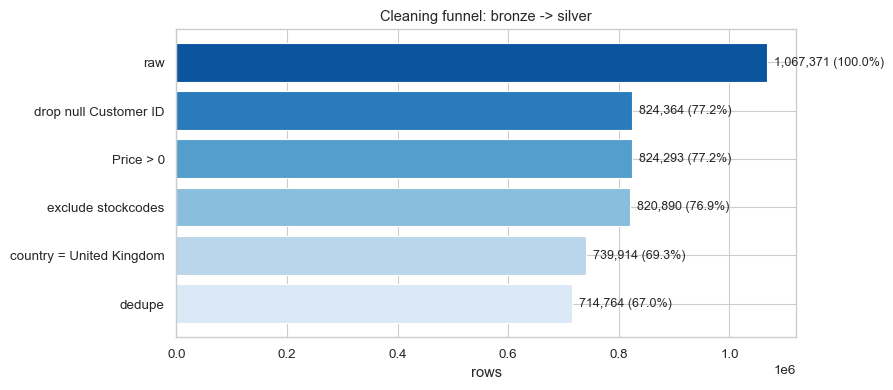

,step,rows,pct_of_raw
0,raw,1067371,100.0
1,drop null Customer ID,824364,77.2
2,Price > 0,824293,77.2
3,exclude stockcodes,820890,76.9
4,country = United Kingdom,739914,69.3
5,dedupe,714764,67.0


In [5]:
def cleaning_funnel(df, excluded, country):
    df = df.copy()
    df["StockCode"] = df["StockCode"].astype(str).str.strip().str.upper()
    steps = [("raw", len(df))]
    df = df.dropna(subset=["Customer ID"])
    steps.append(("drop null Customer ID", len(df)))
    df = df[df["Price"] > 0]
    steps.append(("Price > 0", len(df)))
    exact = {s.upper() for s in excluded if not s.endswith("*")}
    prefixes = [s.upper()[:-1] for s in excluded if s.endswith("*")]
    mask = df["StockCode"].isin(exact)
    for p in prefixes:
        mask = mask | df["StockCode"].str.startswith(p)
    df = df[~mask]
    steps.append(("exclude stockcodes", len(df)))
    df = df[df["Country"] == country]
    steps.append((f"country = {country}", len(df)))
    df = df.drop_duplicates()
    steps.append(("dedupe", len(df)))
    return pd.DataFrame(steps, columns=["step", "rows"])


funnel = cleaning_funnel(bronze, settings["excluded_stockcodes"], settings["country_filter"])
funnel["pct_of_raw"] = (funnel["rows"] / funnel["rows"].iloc[0] * 100).round(1)

fig, ax = plt.subplots(figsize=(8, 4))
ax.barh(funnel["step"], funnel["rows"], color=sns.color_palette("Blues_r", len(funnel)))
ax.invert_yaxis()
ax.set_xlabel("rows")
ax.set_title("Cleaning funnel: bronze -> silver")
for i, (r, p) in enumerate(zip(funnel["rows"], funnel["pct_of_raw"])):
    ax.text(r, i, f"  {r:,} ({p}%)", va="center", fontsize=9)
savefig(fig, "cleaning_funnel")
plt.show()
funnel

## 3. Geographic distribution

The UK dominates the dataset; this justifies scoping the analysis to UK transactions only.

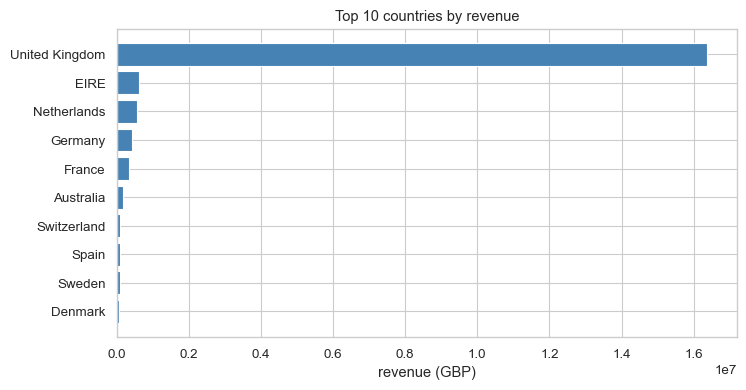

UK share of revenue: 84.94%


,rows,revenue,revenue_pct
Country,,,
United Kingdom,981330,1.638258e+07,84.94
EIRE,17866,6.155196e+05,3.19
Netherlands,5140,5.485249e+05,2.84
Germany,17624,4.179886e+05,2.17
France,14330,3.281918e+05,1.70
Australia,1913,1.671291e+05,0.87
Switzerland,3189,9.972876e+04,0.52
Spain,3811,9.185948e+04,0.48
Sweden,1364,8.780942e+04,0.46


In [6]:
b = bronze.assign(Revenue=bronze["Quantity"] * bronze["Price"])
country = (b.groupby("Country")
            .agg(rows=("Invoice", "size"), revenue=("Revenue", "sum"))
            .sort_values("revenue", ascending=False))
country["revenue_pct"] = (country["revenue"] / country["revenue"].sum() * 100).round(2)
savetable(country, "country_distribution")

top = country.head(10)
fig, ax = plt.subplots(figsize=(8, 4))
ax.barh(top.index, top["revenue"], color="steelblue")
ax.invert_yaxis()
ax.set_xlabel("revenue (GBP)")
ax.set_title("Top 10 countries by revenue")
savefig(fig, "country_revenue")
plt.show()
print(f"UK share of revenue: {country.loc['United Kingdom', 'revenue_pct']}%")
top

## 4. Temporal trends (silver, purchases)

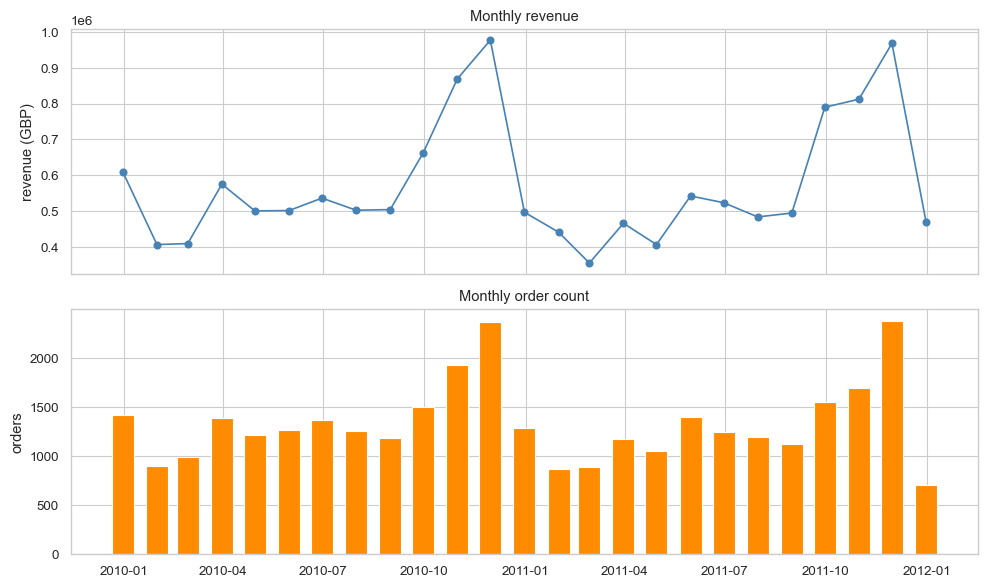

In [7]:
purchases, returns = split_purchases_returns(silver)
monthly = (purchases.set_index("InvoiceDate")
           .resample("ME")
           .agg(revenue=("Revenue", "sum"), orders=("Invoice", "nunique")))

fig, axes = plt.subplots(2, 1, figsize=(10, 6), sharex=True)
axes[0].plot(monthly.index, monthly["revenue"], marker="o", color="steelblue")
axes[0].set_ylabel("revenue (GBP)")
axes[0].set_title("Monthly revenue")
axes[1].bar(monthly.index, monthly["orders"], width=20, color="darkorange")
axes[1].set_ylabel("orders")
axes[1].set_title("Monthly order count")
fig.tight_layout()
savefig(fig, "monthly_trends")
plt.show()

## 5. Seasonality

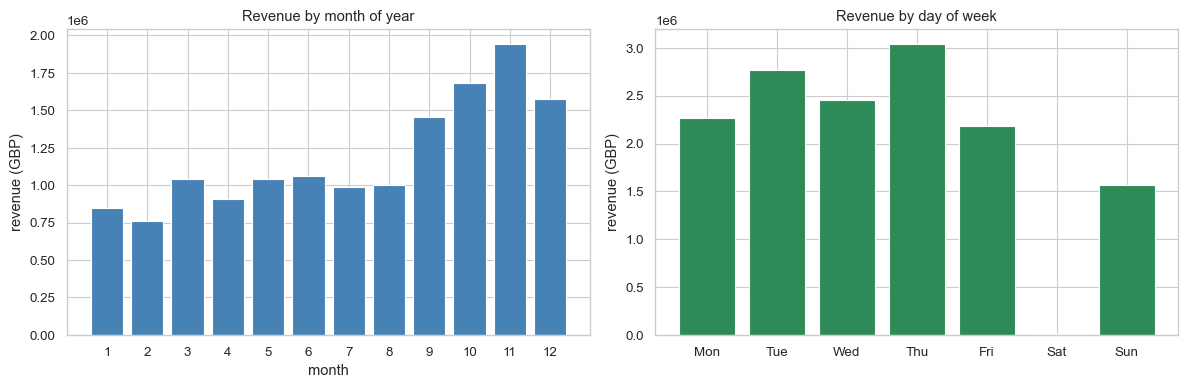

In [8]:
p = purchases.assign(
    month=purchases["InvoiceDate"].dt.month,
    dow=purchases["InvoiceDate"].dt.dayofweek,
)
by_month = p.groupby("month")["Revenue"].sum()
dow_names = ["Mon", "Tue", "Wed", "Thu", "Fri", "Sat", "Sun"]
by_dow = p.groupby("dow")["Revenue"].sum().reindex(range(7))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].bar(by_month.index, by_month.values, color="steelblue")
axes[0].set_xticks(range(1, 13))
axes[0].set_xlabel("month")
axes[0].set_ylabel("revenue (GBP)")
axes[0].set_title("Revenue by month of year")
axes[1].bar(dow_names, by_dow.values, color="seagreen")
axes[1].set_ylabel("revenue (GBP)")
axes[1].set_title("Revenue by day of week")
fig.tight_layout()
savefig(fig, "seasonality")
plt.show()

## 6. Top products

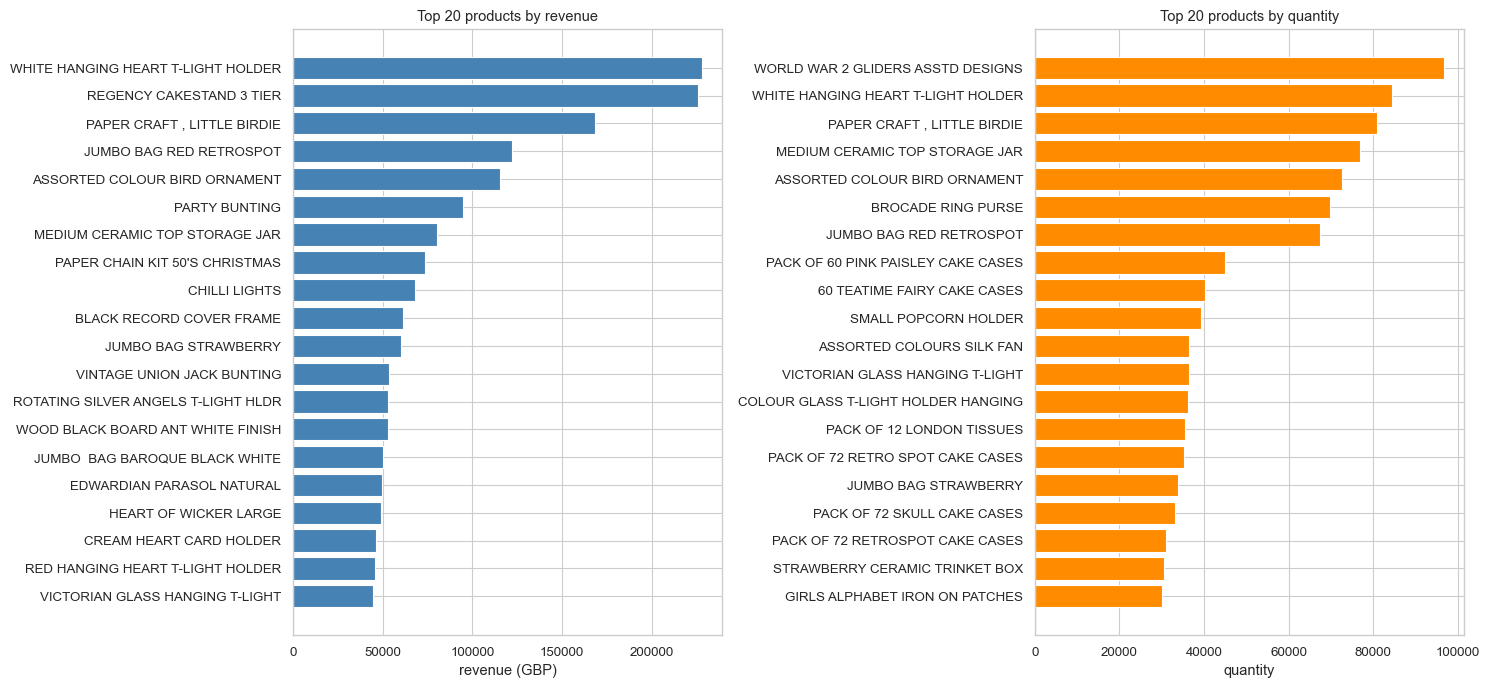

In [9]:
top_rev = purchases.groupby("Description")["Revenue"].sum().nlargest(20)
top_qty = purchases.groupby("Description")["Quantity"].sum().nlargest(20)
savetable(top_rev.rename("revenue").to_frame(), "top20_revenue")
savetable(top_qty.rename("quantity").to_frame(), "top20_quantity")

fig, axes = plt.subplots(1, 2, figsize=(15, 7))
axes[0].barh(top_rev.index[::-1], top_rev.values[::-1], color="steelblue")
axes[0].set_xlabel("revenue (GBP)")
axes[0].set_title("Top 20 products by revenue")
axes[1].barh(top_qty.index[::-1], top_qty.values[::-1], color="darkorange")
axes[1].set_xlabel("quantity")
axes[1].set_title("Top 20 products by quantity")
fig.tight_layout()
savefig(fig, "top_products")
plt.show()

## 7. Returns

Purchase lines: 699,681   Return lines: 15,083
Return rate (lines): 2.11%
Return value: GBP 629,148  (4.40% of purchase value)


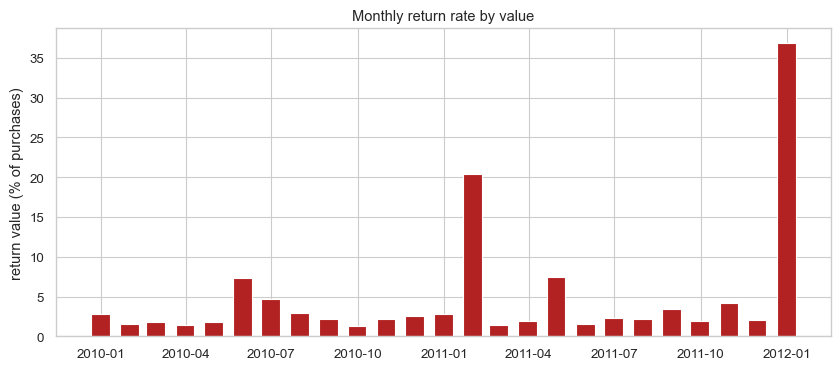

In [10]:
n_pur, n_ret = len(purchases), len(returns)
pur_value = purchases["Revenue"].sum()
ret_value = -returns["Revenue"].sum()
print(f"Purchase lines: {n_pur:,}   Return lines: {n_ret:,}")
print(f"Return rate (lines): {n_ret / len(silver) * 100:.2f}%")
print(f"Return value: GBP {ret_value:,.0f}  ({ret_value / pur_value * 100:.2f}% of purchase value)")

ret_m = -returns.set_index("InvoiceDate")["Revenue"].resample("ME").sum()
pur_m = purchases.set_index("InvoiceDate")["Revenue"].resample("ME").sum()
rate_m = ret_m / pur_m * 100

fig, ax = plt.subplots(figsize=(10, 4))
ax.bar(rate_m.index, rate_m.values, width=20, color="firebrick")
ax.set_ylabel("return value (% of purchases)")
ax.set_title("Monthly return rate by value")
savefig(fig, "returns_monthly")
plt.show()

## 8. Customer & basket distributions

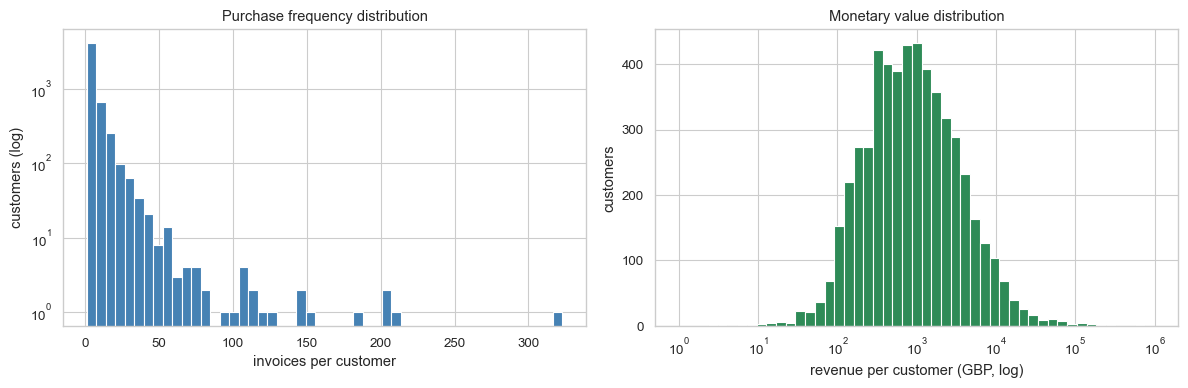

Top 20% of customers account for 75.9% of revenue


In [11]:
cust = purchases.groupby("Customer ID").agg(
    invoices=("Invoice", "nunique"), revenue=("Revenue", "sum"))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(cust["invoices"], bins=50, color="steelblue")
axes[0].set_yscale("log")
axes[0].set_xlabel("invoices per customer")
axes[0].set_ylabel("customers (log)")
axes[0].set_title("Purchase frequency distribution")
axes[1].hist(cust["revenue"].clip(lower=1), bins=np.logspace(0, 6, 50), color="seagreen")
axes[1].set_xscale("log")
axes[1].set_xlabel("revenue per customer (GBP, log)")
axes[1].set_ylabel("customers")
axes[1].set_title("Monetary value distribution")
fig.tight_layout()
savefig(fig, "customer_distributions")
plt.show()

cust_sorted = cust["revenue"].sort_values(ascending=False)
cum_share = cust_sorted.cumsum() / cust_sorted.sum()
top20_share = cum_share.iloc[int(len(cust_sorted) * 0.2)]
print(f"Top 20% of customers account for {top20_share * 100:.1f}% of revenue")

         lines    items
count  33374.0  33374.0
mean      20.7    255.4
std       22.4    924.7
min        1.0      1.0
25%        6.0     72.0
50%       15.0    147.0
75%       27.0    274.0
max      540.0  87167.0


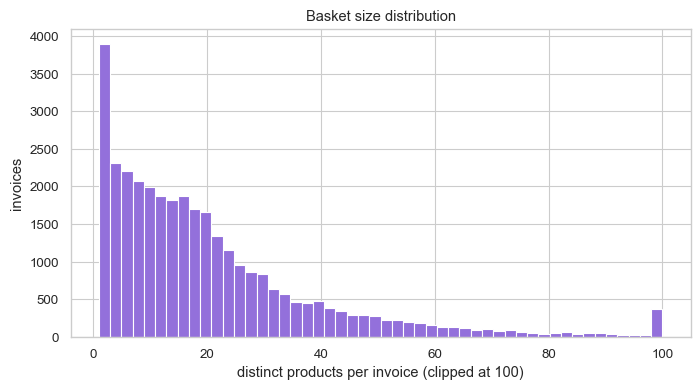

In [12]:
basket = purchases.groupby("Invoice").agg(
    lines=("StockCode", "nunique"), items=("Quantity", "sum"))
print(basket.describe().round(1))

fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(basket["lines"].clip(upper=100), bins=50, color="mediumpurple")
ax.set_xlabel("distinct products per invoice (clipped at 100)")
ax.set_ylabel("invoices")
ax.set_title("Basket size distribution")
savefig(fig, "basket_size")
plt.show()

## Key findings

- **Volume & span.** ~1.07M raw transaction lines spanning Dec 2009 – Dec 2011;
  cleaning retains ~67% as the UK silver layer.
- **Missing customers.** Customer ID is absent in a large share of raw rows; these
  are dropped, since all downstream analysis is customer-level.
- **Geography.** The UK accounts for the overwhelming majority of revenue, which
  motivates the UK-only scope.
- **Seasonality.** Revenue is strongly seasonal, peaking in the autumn pre-Christmas
  window. Dec 2009 and Dec 2011 are partial months. No Saturday transactions appear —
  a known artefact of this dataset.
- **Concentration (Pareto).** A small set of products and a minority of customers
  drive most revenue — long-tailed frequency and monetary distributions that
  motivate RFM segmentation.
- **Returns.** Modest in line count but non-trivial in value, justifying the
  separate handling of purchases vs. returns.